# Bank Customer Segmentation — End-to-End Clustering

## Business Case
A bank wants to discover natural groups of customers based on financial profile, transaction behavior, digital activity, product ownership, and relationship tenure.

This is **unsupervised Machine Learning**: there is no predefined target/label.

> The dataset is synthetic for education and is not suitable for real customer decisions.

## 1. Clustering vs Classification

**Classification:** the label is known, e.g. Fraud / Normal.

**Clustering:** there is no label; the algorithm discovers groups based on similarity.

Typical banking uses:
- customer segmentation
- personalized marketing
- cross-sell analysis
- digital adoption
- relationship management
- customer value analysis

## 2. Dataset

| Variable | Meaning |
|---|---|
| Customer_ID | Identifier |
| Age | Customer age |
| Annual_Income | Annual income |
| Average_Monthly_Balance | Average balance |
| Monthly_Transactions | Monthly transaction count |
| Digital_Transactions_Pct | Digital transaction percentage |
| Credit_Card_Count | Number of cards |
| Existing_Loan_Count | Existing loans |
| Investment_Balance | Investment balance |
| Tenure_Years | Relationship tenure |
| Monthly_Income | Derived monthly income |

There is no target variable.

## 3. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, scikit-learn for scaling and K-Means, and Matplotlib/Seaborn for visualisation — and silences non-critical warnings so the output stays readable.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

## 4. Load Data

The customer clustering dataset is loaded from its CSV file into a pandas DataFrame. Every row is one retail customer described by behavioural and demographic attributes.


In [2]:
DATA_PATH=Path("bank_customer_clustering_sample.csv")
df=pd.read_csv(DATA_PATH)
print("Rows:",len(df),"Columns:",len(df.columns))
df.head()

Rows: 5000 Columns: 11


,Customer_ID,Age,Annual_Income,Average_Monthly_Balance,Monthly_Transactions,Digital_Transactions_Pct,Credit_Card_Count,Existing_Loan_Count,Investment_Balance,Tenure_Years,Monthly_Income
0,C00001,25,113800000.0,53800000.0,31,64.9,2,0,7800000.0,17.8,9500000.0
1,C00002,55,108800000.0,129900000.0,22,53.2,2,1,89900000.0,4.3,9100000.0
2,C00003,50,213700000.0,117900000.0,29,100.0,0,2,441200000.0,11.0,17800000.0
3,C00004,40,219700000.0,45300000.0,19,42.3,0,0,17200000.0,3.3,18300000.0
4,C00005,40,104300000.0,6200000.0,25,71.3,0,1,25600000.0,1.4,8700000.0


## 5. Data Understanding & Quality

Dtypes, summary statistics and missing-value counts are inspected before clustering. K-Means cannot handle missing values or text categories directly, so this step defines exactly what cleaning the data needs.


In [3]:
df.info()
display(df.describe().T)
print("Duplicate rows:",df.duplicated().sum())
display(df.isna().sum().to_frame("Missing").query("Missing>0"))

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               5000 non-null   str    
 1   Age                       5000 non-null   int64  
 2   Annual_Income             5000 non-null   float64
 3   Average_Monthly_Balance   4900 non-null   float64
 4   Monthly_Transactions      5000 non-null   int64  
 5   Digital_Transactions_Pct  4900 non-null   float64
 6   Credit_Card_Count         5000 non-null   int64  
 7   Existing_Loan_Count       5000 non-null   int64  
 8   Investment_Balance        4900 non-null   float64
 9   Tenure_Years              5000 non-null   float64
 10  Monthly_Income            5000 non-null   float64
dtypes: float64(6), int64(4), str(1)
memory usage: 459.1 KB


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,4.294140e+01,1.302086e+01,21.0,3.200000e+01,4.300000e+01,54.0,6.500000e+01
Annual_Income,5000.0,1.642804e+08,9.825225e+07,12500000.0,9.720000e+07,1.398500e+08,204300000.0,9.358000e+08
Average_Monthly_Balance,4900.0,6.364339e+07,7.008609e+07,2200000.0,2.510000e+07,4.380000e+07,77600000.0,1.533400e+09
Monthly_Transactions,5000.0,2.810780e+01,5.330503e+00,11.0,2.400000e+01,2.800000e+01,32.0,4.900000e+01
Digital_Transactions_Pct,4900.0,6.496665e+01,1.940392e+01,5.0,5.167500e+01,6.555000e+01,78.9,1.000000e+02
Credit_Card_Count,5000.0,1.411000e+00,1.175906e+00,0.0,1.000000e+00,1.000000e+00,2.0,6.000000e+00
Existing_Loan_Count,5000.0,1.100600e+00,1.046852e+00,0.0,0.000000e+00,1.000000e+00,2.0,5.000000e+00
Investment_Balance,4900.0,4.387596e+07,6.103903e+07,300000.0,1.180000e+07,2.480000e+07,51225000.0,9.519000e+08
Tenure_Years,5000.0,1.018936e+01,5.703016e+00,0.2,5.300000e+00,1.030000e+01,15.1,2.000000e+01
Monthly_Income,5000.0,1.369040e+07,8.187277e+06,1000000.0,8.100000e+06,1.165000e+07,17000000.0,7.800000e+07


Duplicate rows: 0


,Missing
Average_Monthly_Balance,100
Digital_Transactions_Pct,100
Investment_Balance,100


## 6. Select Features
Exclude `Customer_ID` because it is an identifier. There is no target variable.

In [4]:
features=[
"Age","Annual_Income","Average_Monthly_Balance",
"Monthly_Transactions","Digital_Transactions_Pct",
"Credit_Card_Count","Existing_Loan_Count",
"Investment_Balance","Tenure_Years","Monthly_Income"
]
X=df[features].copy()
X.head()

,Age,Annual_Income,Average_Monthly_Balance,Monthly_Transactions,Digital_Transactions_Pct,Credit_Card_Count,Existing_Loan_Count,Investment_Balance,Tenure_Years,Monthly_Income
0,25,113800000.0,53800000.0,31,64.9,2,0,7800000.0,17.8,9500000.0
1,55,108800000.0,129900000.0,22,53.2,2,1,89900000.0,4.3,9100000.0
2,50,213700000.0,117900000.0,29,100.0,0,2,441200000.0,11.0,17800000.0
3,40,219700000.0,45300000.0,19,42.3,0,0,17200000.0,3.3,18300000.0
4,40,104300000.0,6200000.0,25,71.3,0,1,25600000.0,1.4,8700000.0


## 7. Preprocessing

K-Means uses distance. Income and balance are measured in very large units while card counts are small, so standardization is important.

Steps:
1. Median imputation for missing numeric values
2. Standard scaling

In [5]:
preprocessor=Pipeline([
("imputer",SimpleImputer(strategy="median")),
("scaler",StandardScaler())
])
X_scaled=preprocessor.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled,columns=features,index=X.index)
X_scaled.head()

,Age,Annual_Income,Average_Monthly_Balance,Monthly_Transactions,Digital_Transactions_Pct,Credit_Card_Count,Existing_Loan_Count,Investment_Balance,Tenure_Years,Monthly_Income
0,-1.378035,-0.513835,-0.136058,0.542630,-0.004078,0.500940,-1.051448,-0.590202,1.334627,-0.511870
1,0.926192,-0.564730,0.960007,-1.145935,-0.613227,0.500940,-0.096107,0.767308,-1.032778,-0.560731
2,0.542154,0.503037,0.787171,0.167393,1.823370,-1.200046,0.859233,6.575995,0.142157,0.502000
3,-0.225922,0.564110,-0.258483,-1.708790,-1.180725,-1.200046,-1.051448,-0.434774,-1.208141,0.563076
4,-0.225922,-0.610535,-0.821638,-0.583080,0.329132,-1.200046,-0.096107,-0.295882,-1.541332,-0.609592


## 8. Exploratory Data Analysis

Distributions and relationships of key features (income, balance, tenure, product usage) are plotted to understand the customer base before grouping it — clustering on unexamined data usually produces unexplainable segments.


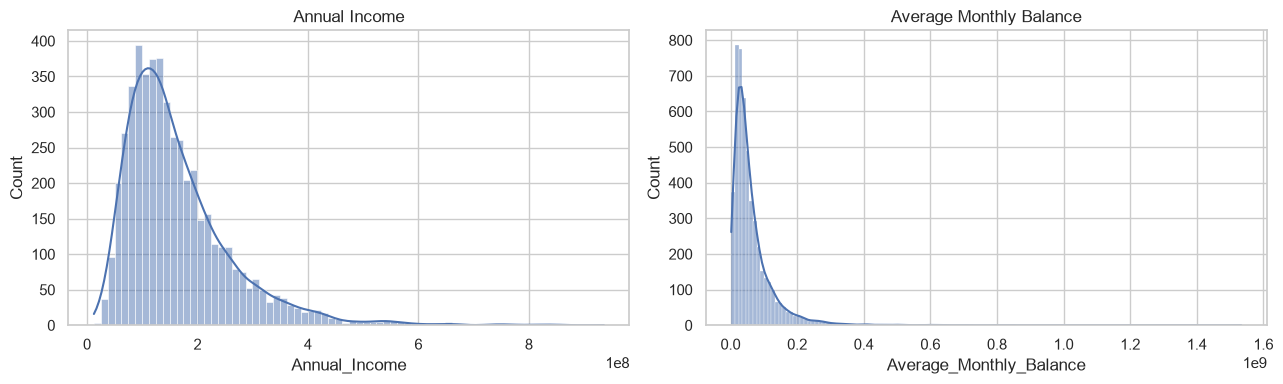

In [6]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
sns.histplot(df["Annual_Income"],kde=True,ax=ax[0]); ax[0].set_title("Annual Income")
sns.histplot(df["Average_Monthly_Balance"],kde=True,ax=ax[1]); ax[1].set_title("Average Monthly Balance")
plt.tight_layout(); plt.show()

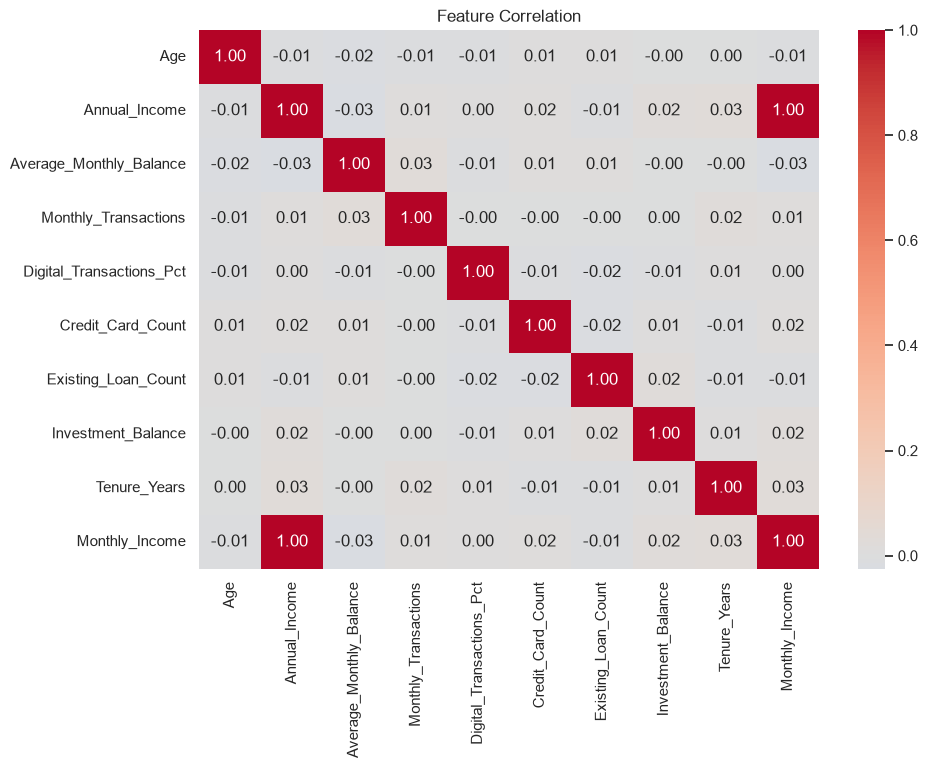

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(X.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Feature Correlation"); plt.show()

## 9. K-Means Concept

K-Means repeatedly:
1. chooses cluster centers,
2. assigns customers to the nearest center,
3. recalculates centers,
4. repeats until the solution stabilizes.

The objective is to minimize within-cluster variation, measured by **inertia**.

## 10. Elbow Method

Inertia (within-cluster sum of squared distances) is plotted for K = 2…10. The elbow — where adding another cluster stops reducing inertia meaningfully — is the first guide for choosing the number of segments.


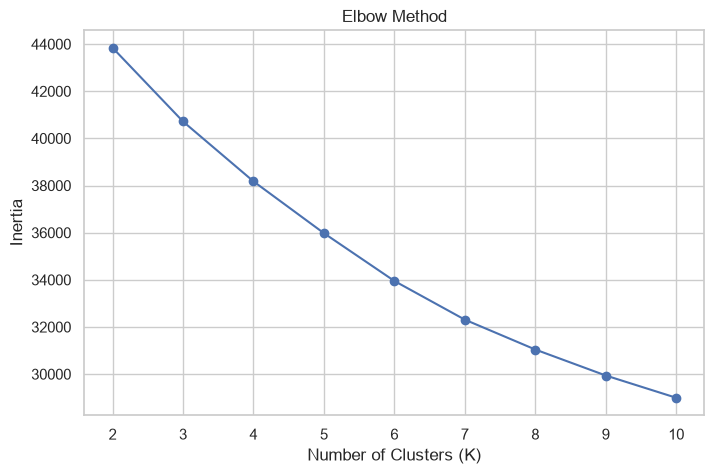

In [8]:
inertias=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42,n_init=20)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(2,11),inertias,marker="o")
plt.xlabel("Number of Clusters (K)"); plt.ylabel("Inertia")
plt.title("Elbow Method"); plt.xticks(range(2,11)); plt.show()

The elbow is a heuristic: look for the point where additional clusters provide diminishing improvement.

## 11. Silhouette Score

The silhouette score measures how well each customer fits its own cluster compared with the nearest other cluster. Computed for every candidate K, it is combined with the elbow plot to select the final number of segments.


,K,Silhouette
0,2,0.1776
1,3,0.1010
2,4,0.1047
3,5,0.1080
4,6,0.1046
5,7,0.1031
6,8,0.0997
7,9,0.1005
8,10,0.0993


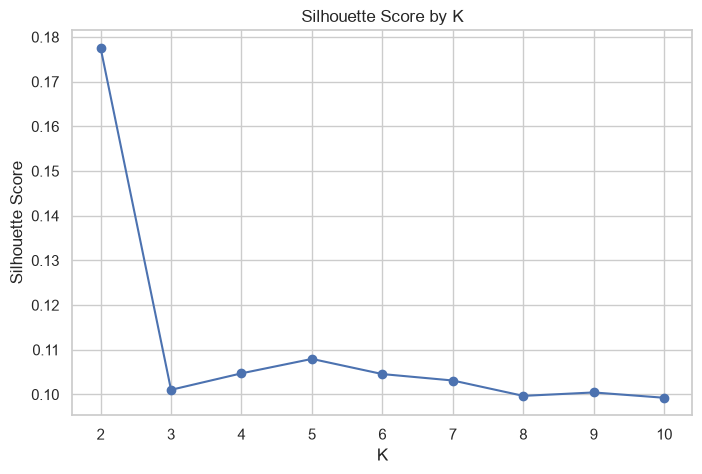

In [9]:
scores=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42,n_init=20)
    labels=model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled,labels))
silhouette_df=pd.DataFrame({"K":range(2,11),"Silhouette":scores})
display(silhouette_df.round(4))
plt.figure(figsize=(8,5))
plt.plot(silhouette_df["K"],silhouette_df["Silhouette"],marker="o")
plt.xlabel("K"); plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K"); plt.xticks(range(2,11)); plt.show()

## 12. Select K

For this educational project we use **K = 4** so the result is easy to interpret as a small number of business segments.

In production, K should consider:
- elbow/inertia
- silhouette
- segment stability
- cluster size
- business interpretability
- operational usefulness

In [10]:
K=4
kmeans=KMeans(n_clusters=K,random_state=42,n_init=20)
df["Cluster"]=kmeans.fit_predict(X_scaled)
display(df["Cluster"].value_counts().sort_index())

Cluster
0    1952
1    2015
2     222
3     811
Name: count, dtype: int64

## 13. Cluster Size

The number of customers per cluster is checked. A segment with a handful of customers is not actionable, and one holding almost the entire base adds no targeting value — both would send us back to the choice of K.


,Customers,Pct
Cluster,,
0,1952,39.04
1,2015,40.30
2,222,4.44
3,811,16.22


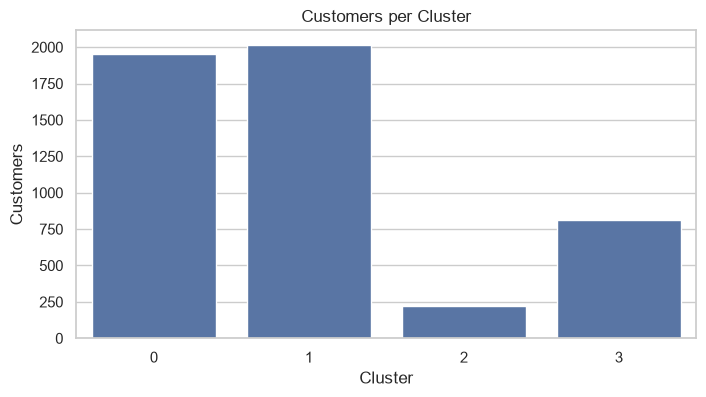

In [11]:
size=df["Cluster"].value_counts().sort_index().to_frame("Customers")
size["Pct"]=size["Customers"]/len(df)*100
display(size.round(2))
plt.figure(figsize=(8,4))
sns.barplot(x=size.index,y=size["Customers"])
plt.title("Customers per Cluster"); plt.xlabel("Cluster"); plt.ylabel("Customers"); plt.show()

## 14. Cluster Profiling

Average feature values per cluster reveal what makes each segment distinct, for example high income but low product count. Profiling is what turns abstract clusters into meaningful customer segments.


In [12]:
cluster_profile=df.groupby("Cluster")[features].mean().T
display(cluster_profile.round(2))

Cluster,0,1,2,3
Age,5.455000e+01,3.189000e+01,4.186000e+01,4.275000e+01
Annual_Income,1.288921e+08,1.312866e+08,1.458234e+08,3.364855e+08
Average_Monthly_Balance,5.938349e+07,7.122221e+07,5.960000e+07,5.607175e+07
Monthly_Transactions,2.808000e+01,2.807000e+01,2.866000e+01,2.810000e+01
Digital_Transactions_Pct,6.487000e+01,6.529000e+01,6.185000e+01,6.525000e+01
Credit_Card_Count,1.340000e+00,1.430000e+00,1.580000e+00,1.480000e+00
Existing_Loan_Count,1.110000e+00,1.090000e+00,1.240000e+00,1.060000e+00
Investment_Balance,3.397501e+07,3.158166e+07,2.519914e+08,4.006239e+07
Tenure_Years,1.026000e+01,9.850000e+00,1.060000e+01,1.075000e+01
Monthly_Income,1.074129e+07,1.094179e+07,1.214865e+07,2.803983e+07


Raw values are useful for business interpretation. Standardized profiles make cross-feature comparison easier.

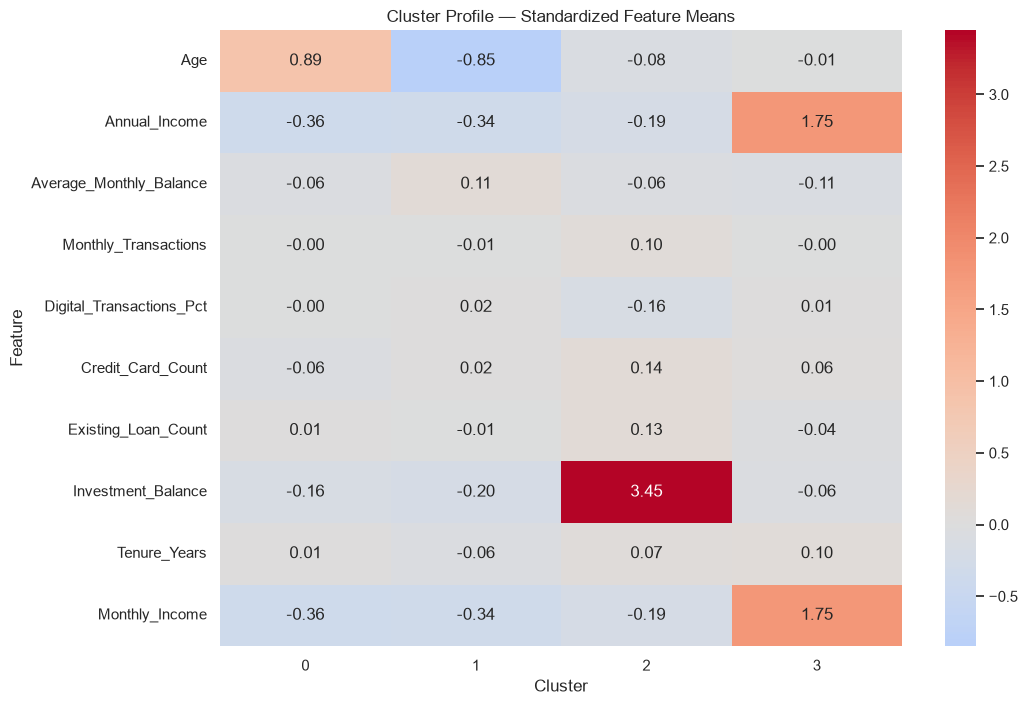

In [13]:
profile_z=X_scaled.assign(Cluster=df["Cluster"].values).groupby("Cluster").mean().T
plt.figure(figsize=(11,8))
sns.heatmap(profile_z,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Cluster Profile — Standardized Feature Means")
plt.xlabel("Cluster"); plt.ylabel("Feature"); plt.show()

## 15. PCA Visualization
PCA reduces the feature space to two dimensions for visualization. It does not mean clustering was performed only in two dimensions.

Explained variance: [0.201 0.104]


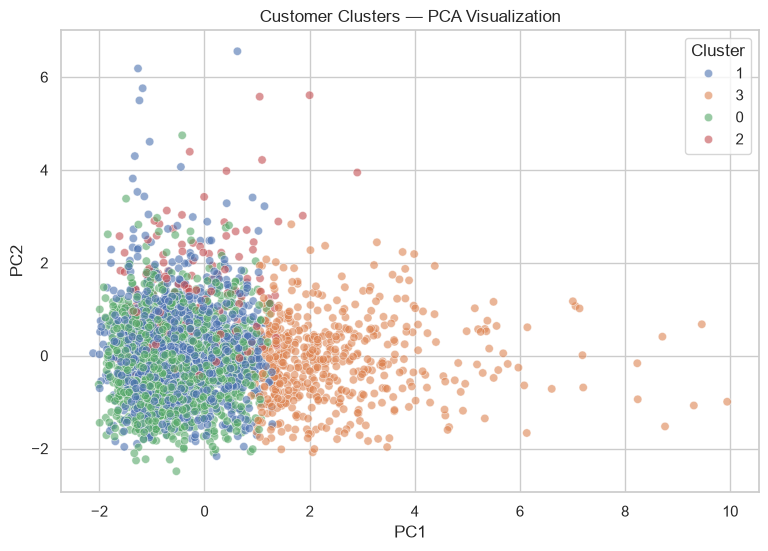

In [14]:
pca=PCA(n_components=2,random_state=42)
Xp=pca.fit_transform(X_scaled)
pca_df=pd.DataFrame({"PC1":Xp[:,0],"PC2":Xp[:,1],"Cluster":df["Cluster"].astype(str)})
print("Explained variance:",np.round(pca.explained_variance_ratio_,3))
plt.figure(figsize=(9,6))
sns.scatterplot(data=pca_df.sample(3000,random_state=42),x="PC1",y="PC2",hue="Cluster",alpha=.6)
plt.title("Customer Clusters — PCA Visualization"); plt.show()

## 16. Business Interpretation

Cluster numbers have no inherent meaning.

Do **not** immediately call Cluster 0 "Premium" or Cluster 1 "Digital".

Instead:
1. inspect cluster profiles,
2. identify distinguishing characteristics,
3. assign descriptive labels,
4. validate with business stakeholders.

Possible validated labels could eventually be:
- Affluent / Investment-oriented
- Digital Active
- Credit-oriented
- Everyday Banking

These are examples, not conclusions from the algorithm alone.

## 17. Business-Friendly Segment Table

Cluster means are translated into a compact table with segment sizes, shares and headline metrics, so marketing and product teams can act on the segments without ever touching the model.


In [15]:
segment_summary=df.groupby("Cluster").agg(
Customers=("Customer_ID","count"),
Avg_Age=("Age","mean"),
Avg_Income=("Annual_Income","mean"),
Avg_Balance=("Average_Monthly_Balance","mean"),
Avg_Transactions=("Monthly_Transactions","mean"),
Avg_Digital_Pct=("Digital_Transactions_Pct","mean"),
Avg_Cards=("Credit_Card_Count","mean"),
Avg_Loans=("Existing_Loan_Count","mean"),
Avg_Investment=("Investment_Balance","mean"),
Avg_Tenure=("Tenure_Years","mean")
).reset_index()
segment_summary["Customer_Pct"]=segment_summary["Customers"]/len(df)*100
display(segment_summary.round(2))

,Cluster,Customers,Avg_Age,Avg_Income,Avg_Balance,Avg_Transactions,Avg_Digital_Pct,Avg_Cards,Avg_Loans,Avg_Investment,Avg_Tenure,Customer_Pct
0,0,1952,54.55,1.288921e+08,59383490.57,28.08,64.87,1.34,1.11,3.397501e+07,10.26,39.04
1,1,2015,31.89,1.312866e+08,71222211.00,28.07,65.29,1.43,1.09,3.158166e+07,9.85,40.30
2,2,222,41.86,1.458234e+08,59600000.00,28.66,61.85,1.58,1.24,2.519914e+08,10.60,4.44
3,3,811,42.75,3.364855e+08,56071752.84,28.10,65.25,1.48,1.06,4.006239e+07,10.75,16.22


## 18. Example Business Actions

After validation, the bank might test hypotheses such as:

| Observed characteristic | Possible action |
|---|---|
| High balance + high investment | Investment/wealth campaign |
| High digital activity | Digital product campaign |
| High loan ownership | Refinancing/cross-sell analysis |
| Low digital activity | Digital adoption campaign |
| High transaction activity | Transaction-based offers |

Clustering identifies similarity; it does not prove that a particular action will work.

## 19. Stability Check

K-Means is re-run with several random seeds and the resulting segmentations are compared. Unstable clusters should not drive campaign design, because the same customer would land in a different segment next quarter.


In [16]:
stability=[]
for seed in [1,7,21,42,99]:
    model=KMeans(n_clusters=K,random_state=seed,n_init=20)
    labels=model.fit_predict(X_scaled)
    stability.append({
        "Seed":seed,
        "Silhouette":silhouette_score(X_scaled,labels),
        "Inertia":model.inertia_
    })
display(pd.DataFrame(stability).round(3))

,Seed,Silhouette,Inertia
0,1,0.105,38176.345
1,7,0.101,38387.410
2,21,0.105,38124.770
3,42,0.105,38176.206
4,99,0.105,38124.825


## 20. Common Clustering Mistakes

1. Including IDs in the model.
2. Not scaling features.
3. Choosing K blindly.
4. Ignoring cluster size.
5. Giving business names before profiling.
6. Treating clusters as causal explanations.
7. Ignoring stability and population drift.
8. Using features that are not available at the intended business decision point.

## 21. Production Architecture

```text
Core Banking / CRM / Digital Channels
                ↓
          Data Warehouse
                ↓
        Feature Engineering
                ↓
       Customer Clustering
                ↓
         Cluster Profile
                ↓
       Business Validation
                ↓
    Segment / Strategy Layer
        ┌───────┼────────┐
        ↓       ↓        ↓
    Marketing   CRM     Analytics
```

Production considerations:
- scheduled clustering
- model/version registry
- feature monitoring
- cluster stability
- population drift
- dashboarding
- audit logging

## 22. Advanced Extensions

### Algorithms
- Hierarchical Clustering
- DBSCAN
- Gaussian Mixture Models

### Analytics
- RFM segmentation
- Customer Lifetime Value
- product-holding segmentation
- digital engagement

### Decisioning
- Next Best Product
- Cross-sell propensity
- churn prediction by segment

### MLOps
- MLflow
- Airflow
- Docker
- automated monitoring

# Final Executive Summary

**Business problem:** understand different customer groups.

**ML problem:** unsupervised customer clustering.

**Main algorithm:** K-Means.

**Diagnostics:** Elbow, Silhouette, cluster size, cluster profiles, PCA visualization, stability checks.

**Key lesson:**

> Clustering is not finished when the algorithm creates clusters. The real work is profiling, validating, naming, and connecting the clusters to measurable business objectives.